In [45]:
import pandas as pd 
import numpy as np

In [46]:
df = pd.read_csv(r'C:\Users\Tuhin\OneDrive\Desktop\DA_All\Data_Projects\Customer_behaviour\shopping_behavior.csv', encoding  = 'utf-8')

In [47]:
df.head(2)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [49]:
df.describe(include = 'all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [50]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

There are 37 null values in review column , which we'll be replacing with category wise mean

In [51]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x : x.fillna(x.median()))

In [52]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [53]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

In [54]:
df.columns = df.columns.str.lower().str.replace(' ','_')

In [55]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

We will bin the age groups

<Axes: >

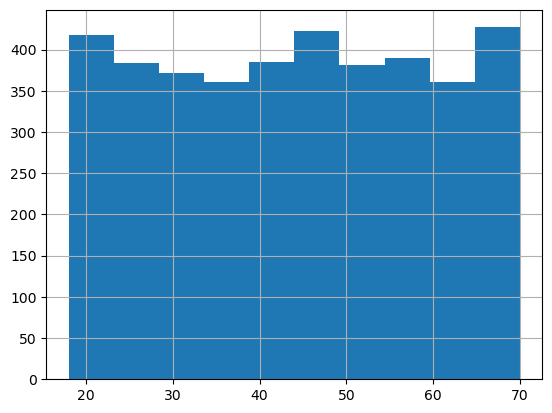

In [56]:
df['age'].hist()

In [57]:
bins = [0,20,30,40,50,np.inf]
labels  = ['Teenage','Young','Adult','Mid-Age','Senior']

df['age_group'] = pd.cut(df['age'],bins = bins, labels = labels, right  = False)

In [58]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Senior
1,19,Teenage
2,50,Senior
3,21,Young
4,45,Mid-Age
5,46,Mid-Age
6,63,Senior
7,27,Young
8,26,Young
9,57,Senior


Freq of purchase is a text column , to make it more useful , we'll create a respective numeric column

In [59]:
df['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [60]:
map_vals = {
    'Fortnightly':15, 'Weekly':7, 'Annually':365, 'Quarterly':90, 'Bi-Weekly':14,
       'Monthly':30, 'Every 3 Months':90
}
df['frequency_of_purchases_days'] = df['frequency_of_purchases'].map(map_vals)

In [61]:
df[['frequency_of_purchases','frequency_of_purchases_days']].drop_duplicates()

,frequency_of_purchases,frequency_of_purchases_days
0,Fortnightly,15
2,Weekly,7
4,Annually,365
6,Quarterly,90
10,Bi-Weekly,14
15,Monthly,30
20,Every 3 Months,90


At this point we can delete the unnessery columns

In [62]:
(df['promo_code_used'] == df['discount_applied']).all()

True

In [63]:
df = df.drop('promo_code_used',axis = 1)

In [64]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount_(usd)', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'frequency_of_purchases_days'],
      dtype='object')

In [65]:
df.shape

(3900, 19)

Connection to SQL

To MSSQL

In [66]:
import pyodbc
from sqlalchemy import create_engine


In [70]:
server = 'ROG-STRIX-SCAR'
database = 'Customer_v1'

engine = create_engine(
    f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

df.to_sql(
    name = 'customer',
   con = engine ,
   if_exists='replace',
   index = False 
)

c:\Users\Tuhin\anaconda3\Lib\site-packages\pandas\io\sql.py:1636: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


50

In [71]:
pyodbc.drivers()

['SQL Server',
 'ODBC Driver 17 for SQL Server',
 'ODBC Driver 18 for SQL Server',
 'Microsoft Access Driver (*.mdb, *.accdb)',
 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)',
 'Microsoft Access Text Driver (*.txt, *.csv)',
 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)']

To MYSQL

In [80]:
import os

In [81]:
# for using the environment variables
from dotenv import load_dotenv 
load_dotenv()

True

In [83]:
os.getenv('db_username')

'root'

In [87]:
import os
engine  = create_engine(
    f"mysql+pymysql://{os.getenv('db_username')}:{os.getenv('db_password')}@{os.getenv('db_server')}/{os.getenv('db_name')}"
)

df.to_sql(
    name = 'Cust',
    con = engine, 
    index = False,
    if_exists= 'replace'
)

C:\Users\Tuhin\AppData\Local\Temp\ipykernel_36420\2647388075.py:6: UserWarning: The provided table name 'Cust' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  df.to_sql(


3900

Further analysis done in sql